In [78]:
# Initialize Otter
import otter
grader = otter.Notebook("geotech_kmeans_homework.ipynb")

# Geotechnical and Geoenvironmental Engineering: Clustering Compaction Tests with K-means

> **Mohamad M. Hallal, PhD** <br> Teaching Professor, UC Berkeley

[![License](https://img.shields.io/badge/license-CC%20BY--NC--ND%204.0-blue)](https://creativecommons.org/licenses/by-nc-nd/4.0/)
***

In [79]:
# Please run this cell, and do not modify the contents

import hashlib
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import whiten, kmeans2, vq

plt.rcParams["figure.figsize"] = (7, 5)
pd.set_option("display.max_columns", 20)

## Background: Proctor Test and Soil-Type Differences

The **Standard Proctor compaction test** (ASTM D698) determines how dry unit weight varies with water content for a given soil. Soil is compacted in a standardized mold at several water contents, and the dry unit weight is measured at each point. The results of this test are used in many areas of geotechnical engineering practice, with the most commonly used attributes from it being the optimal moisture content and maximum dry density.

| Quantity | Symbol | Units | Meaning |
|---|---|---|---|
| **Optimum Moisture Content** | OMC | % | This is the water content where maximum dry unit weight is achieved. Common theory is that water contents below the OMC decrease MDD by introducing more friction, while water contents above the OMC decrease MDD by filling too much of the soil volume with water.|
| **Maximum Dry Density** | MDD | kN/m³ | This is the maximum dry unit weight of a soil under the compaction test. It's value is commonly used to see how dense a soil can be made given a certain method of compaction.|

---

In this assignment, you will use proctor test data to extract the OMC and MDD of many soil samples. You will then explore how these two properties of soils interact with and relate to other soil properties and classifications.

## Part 1: Extracting the OMC and MDD from compaction test data

A regional geotechnical laboratory recently conducted Proctor compaction tests on **36 soil specimens** collected from various sites. Run the cell below to load the CSV file. You do not need to modify this cell.

In the first part of this assignment, we will program a process that can be used to find the OMC and MDD of eeach soil specimen in this data set. 

---

- **`compaction_tests`** — This table holds the data regarding the compaction tests performed on the soil samples. test_id refers to the specific sample of soil while point_id refers to a specific test done to that sample. Looking at the data, you cansee that for soil T01 there were 5 tests done, each giving us a different point on the moisture content vs dry unit weight curve.


In [90]:
# Run this cell — do not modify this part
compaction_tests   = pd.read_csv("resources/proctor_curves.csv")

# Printing out shape of the compaction_tests table and sample of the table
print("compaction_tests table shape:", compaction_tests.shape)
print("\ncompaction_tests table (first 10 rows):")
display(compaction_tests.head(10))

compaction_tests table shape: (180, 4)

compaction_tests table (first 10 rows):


,test_id,point_id,moisture_content_pct,dry_unit_weight_kN_m3
0,T01,1,6.80,17.495
1,T01,2,8.59,18.274
2,T01,3,11.02,18.758
3,T01,4,13.00,18.272
4,T01,5,14.82,17.520
5,T02,1,6.54,17.937
6,T02,2,8.55,18.904
7,T02,3,10.56,19.206
8,T02,4,12.99,18.639
9,T02,5,14.35,17.941


## Question 1: Fit a Polynomial to a Compaction Curve

There are many ways one could find the omptimum moisture content (OMC) and maximum dry density (MDD) of a soil. A simple way could be to take the sample with the largest dry density and use its mositure content and dry density as the OMC and MDD respectively. This method however is sensitive to measurement noise and experimental error. The test done on the sample at the optimal moisture content is not guarenteed to be measured or done completely accurately. As you may have seen in class, a commonly used method in practice is to fit a parabolic curve through the data points that you get from the compaction test and take the peak of this curve to be the point with coordinates equal to the OMC and MDD. We will mimic this process using a computer program so that it may be easily applied to the whole data set in an objective and accurate manner.

Write a function named `fitProctorCurve` that fits a polynomial of a given degree to a set of compaction measurements and returns the resulting polynomial as a function. We will use this function later to get the OMC and MDD by obtaining its peak.

### Input arguments

| Argument | Type | Description |
|---|---|---|
| `moisture_pcts` | array-like | These are the moisture content values for each compaction point (%) |
| `dry_unit_weights` | array-like | The dry unit weights corresponding to the moisture content values (kN/m³) |
| `degree` | int | The degree of the fitting polynomial (default is `2` for a quadratic shape) |

### Output

| Return value | Type | Description |
|---|---|---|
| `poly_fn` | `numpy.poly1d` | A polynomial function fitted to the compaction data. |

---
We have provided sample code below that creates a figure of the polynomial fitting on a soil sample using the `fitProctorCurve()` function that you create. Use it to visualize and verify your funcion. An example curve fitted to a two degree polynomial is shown below.
<center><img src="resources/Curve_Example.png" width='650'/></center>
    
---
For testing purposes, please use np.polyfit in order to fit your polynomials. If you don't, your code may not pass the autograder. Documentation is linked below. We also encourage querying an AI tool to help with the process if you don't quite understand how the functions work.
- np.polyfit (getting polynmial coefficients): https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html
- np.poly1d (turning coefficients into usable function): nhttps://numpy.org/doc/stable/reference/generated/numpy.poly1d.html

In [91]:
def fitProctorCurve(moisture_pcts, dry_unit_weights, degree=2):
    # Convert to NumPy arrays for use
    moisture_pcts    = np.array(moisture_pcts)
    dry_unit_weights = np.array(dry_unit_weights)
    
    # Get polynomial coefficients using np.polyfit
    coeffs = np.polyfit(moisture_pcts, dry_unit_weights, degree) # SOLUTION

    # Create function from coefficients using np.poly1d
    poly_fn = np.poly1d(coeffs) # SOLUTION

    return poly_fn

### Helper Visualization

Run the cell below after implementing `fitProctorCurve` by assigning example_id to the soil sample you would like to plot (ex. example_id = "T01"). A good fit will pass smoothly through the data points and show a clear peak.

Note: Make sure not to change the name of the parameter "example_id". This is for grading purposes.

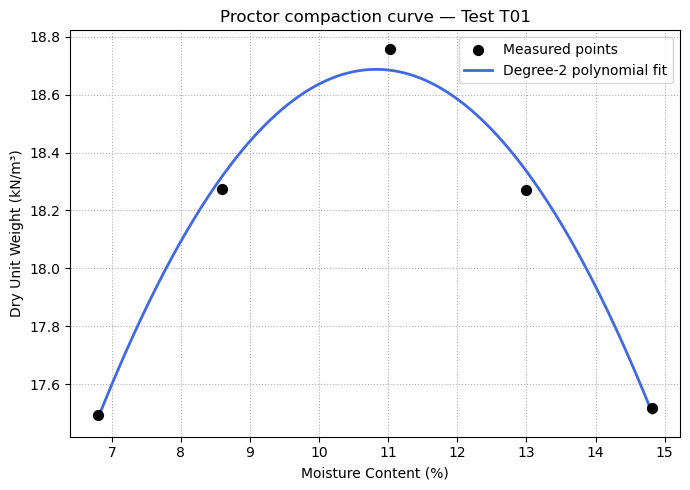

In [92]:
# Helper cell: plots one fitted compaction curve. We made this using an AI tool, and encourage using LLMs to quickly scope out how data looks like by plotting.
example_id = "T01" # SOLUTION

one_curve = compaction_tests[compaction_tests["test_id"] == example_id].sort_values("moisture_content_pct")
w  = one_curve["moisture_content_pct"].to_numpy()
gd = one_curve["dry_unit_weight_kN_m3"].to_numpy()

poly_fn_example = fitProctorCurve(w, gd, degree=2)
w_smooth = np.linspace(w.min(), w.max(), 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(w, gd, color="black", zorder=5, s=50, label="Measured points")
ax.plot(w_smooth, poly_fn_example(w_smooth), color="royalblue", linewidth=2,
        label="Degree-2 polynomial fit")
ax.set_xlabel("Moisture Content (%)")
ax.set_ylabel("Dry Unit Weight (kN/m³)")
ax.set_title(f"Proctor compaction curve — Test {example_id}")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.8)
plt.tight_layout()
plt.show()

#### Testing Cell:

In [93]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to test your function!
""" # END TEST CONFIG

# Check students tested the function (type is not ellipsis)
assert get_hash(type(example_id)) != '14e736438b115821cbb9b7ac0ba79034'

In [94]:
# Sanity-check fitProctorCurve against a known dataset

""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion is getting some calculations wrong!
success_message: Function correctly passes all test cases :D
""" # END TEST CONFIG

_w_test  = [8, 10, 12, 14, 16, 18]
_gd_test = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]
q1 = fitProctorCurve(_w_test, _gd_test, degree=2)

assert get_hash(round(float(q1(9)),  1)) == "1b7f864ac7a422c1a24c720d543e7e0f", \
    "fitProctorCurve: unexpected value at w=9"
assert get_hash(round(float(q1(10)), 1)) == "1383c2b19889c144c1c67203d8f7d201", \
    "fitProctorCurve: unexpected value at w=10"
assert get_hash(round(float(q1(13)), 1)) == "4652e04e446dd7e02c704d4189292a1c", \
    "fitProctorCurve: unexpected value at w=13"
print("fitProctorCurve ✓ all checks passed")

fitProctorCurve ✓ all checks passed


## Question 2: Extract OMC and MDD from the Fitted Curve

Now that you can fit a polynomial to a compaction curve, you need to find its **peak** — the point where dry unit weight is maximized. This peak defines the OMC (Optimal Moisture Content) and MDD (Maximum Dry Density).

For a degree-2 polynomial, the peak is a single well-defined maximum that can be found using basic calculus. For higher degree polynomials, a practical and numerically robust approach is to evaluate the polynomial at many closely spaced moisture content values and find which one gives the highest dry unit weight. This sampling method is an example of a procedure called grid search, and is relatively easy in this case since were trying to maximize across a 1D domain which is bounded.

Write a function named `computeOMC_MDD` that returns the OMC and MDD from a fitted polynomial by sampling the polynomial in 1000 equally spaced points from w_min to w_max.

### Input arguments

| Argument | Type | Description |
|---|---|---|
| `poly_fn` | `numpy.poly1d` | This is the polynomial function from `fitProctorCurve`. Calling `poly_fn(x)` outputs the y value of the polynomial curve at point x. (In this case the dry density at inputted moisture content). |
| `w_min` | float | Lower bound of the moisture content range (%) |
| `w_max` | float | Upper bound of the moisture content range (%) |

### Output

| Return value | Type | Description |
|---|---|---|
| `omc` | float | Optimum moisture content (%) |
| `mdd` | float | Maximum dry unit weight (kN/m³) |

### Hints
- Create a dense array of moisture contents with `np.linspace(w_min, w_max, 1000)`.
- Evaluate the polynomial at each point with `poly_fn(w_dense)`.
- Use `np.argmax` to locate the index of the maximum dry unit weight.
- Return `omc` and `mdd` as Python `float` values (cast with `float(...)`).

In [95]:
def computeOMC_MDD(poly_fn, w_min, w_max):

    # Making array of equally spaced points to call the function on
    moisture_contents  = np.linspace(w_min, w_max, 1000)

    # Use the poly function to get densities at specified moisture contents 
    dry_densities = poly_fn(moisture_contents)           # SOLUTION

    # get the index of this dry density array with the max value
    idx_max  = np.argmax(dry_densities)               # SOLUTION

    # Extract the values for optimum moisture content and maximum dry density using this index
    omc = float(moisture_contents[idx_max])                     
    mdd = float(dry_densities[idx_max])    # SOLUTION                
    return omc, mdd

### Helper Visualization

Run the cell below after implementing `computeOMC_MDD` by assigning ex_id to the soil sample you would like to plot (ex. ex_id = "T01"). This will plot the compaction curve along with the peak that we compute from `computeOMC_MDD`. Make sure the peak we get aligns with the actual peak of the curve.

Note: Make sure not to change the name of the parameter "ex_id". This is for grading purposes.

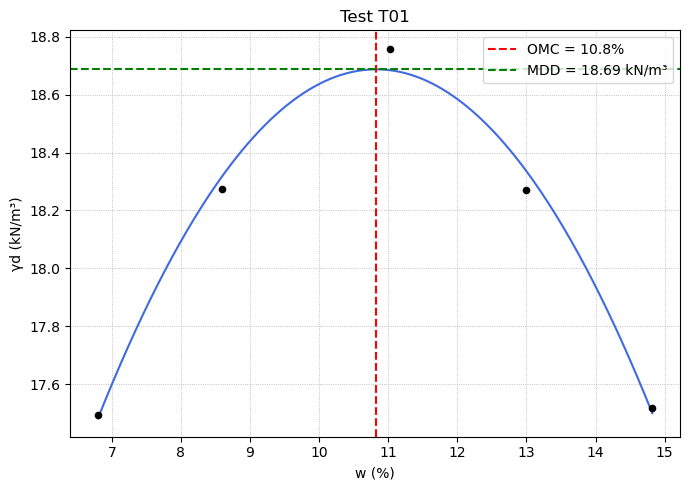

In [96]:
# Helper: show fitted curve with OMC and MDD for a single test
ex_id = "T01"

one = compaction_tests[compaction_tests["test_id"] == ex_id].sort_values("moisture_content_pct")
w   = one["moisture_content_pct"].to_numpy()
gd  = one["dry_unit_weight_kN_m3"].to_numpy()

poly = fitProctorCurve(w, gd, degree=2)
omc, mdd = computeOMC_MDD(poly, w.min(), w.max())

w_smooth = np.linspace(w.min(), w.max(), 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(w, gd, color="black", s=20, zorder=5)
ax.plot(w_smooth, poly(w_smooth), color="royalblue")
ax.axvline(omc, color="red",   linestyle="--", label=f"OMC = {omc:.1f}%")
ax.axhline(mdd, color="green", linestyle="--", label=f"MDD = {mdd:.2f} kN/m³")
ax.set_title(f"Test {ex_id}")
ax.set_xlabel("w (%)")
ax.set_ylabel("γd (kN/m³)")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.6)
plt.tight_layout()
plt.show()

#### Testing Cell:

In [97]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to test your function!
""" # END TEST CONFIG

# Check students tested the function (type is not ellipsis)
assert get_hash(type(ex_id)) != '14e736438b115821cbb9b7ac0ba79034'

In [98]:
# Check computeOMC_MDD on a known polynomial

""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion fitProctorCurve is getting some calculations wrong!
success_message: Function passes all test cases :D
""" # END TEST CONFIG

_w_test  = [8, 10, 12, 14, 16, 18]
_gd_test = [16.5, 17.8, 18.6, 18.9, 18.4, 17.6]
_poly    = fitProctorCurve(_w_test, _gd_test, degree=2)
q2_omc, q2_mdd = computeOMC_MDD(_poly, min(_w_test), max(_w_test))

assert abs(q2_omc - 13.8) < 0.5, \
    f"computeOMC_MDD: OMC = {q2_omc:.2f}, expected near 13.8"
assert abs(q2_mdd - 18.9) < 0.2, \
    f"computeOMC_MDD: MDD = {q2_mdd:.3f}, expected near 18.9"
print(f"computeOMC_MDD ✓  OMC = {q2_omc:.2f}%,  MDD = {q2_mdd:.3f} kN/m³")

computeOMC_MDD ✓  OMC = 13.78%,  MDD = 18.826 kN/m³


## Background: K-means Clustering

**K-means** is an unsupervised machine learning algorithm that partitions a dataset into $k$ groups, or clusters, by grouping datapoints which are geometrically close to each other. It works as follows:

1. **Initialize** $k$ centroids (starting positions in feature space).
2. **Assign** each observation to the nearest centroid using Euclidean distance.
3. **Update** each centroid to the mean of all observations assigned to it.
4. **Repeat** steps 2–3 until assignments no longer change.

The result is $k$ clusters, each defined by a centroid, where observations within a cluster are more similar to each other than to observations in other clusters.

### Key properties

| Property | Description |
|---|---|
| **Unsupervised** | No labels are needed — the algorithm finds structure in the data on its own |
| **Distance-based** | Uses Euclidean distance, so features must be on a comparable scale (This gives a reasoning for why the whitening process is used, which will be described later) |
| **Sensitive to initialization** | Different starting centroids can yield different results |
| **You choose $k$** | The number of clusters must be specified in advance based on prior knowledge or heuristics |

---

A helpful youtube video is linked here https://www.youtube.com/watch?v=4b5d3muPQmA. Feel free to look up more online. There's lots of great visualizations and explanations on the web!

## Part 2: Exploring the OMC and MDD using k-means clustering

In the first part of this assignment, we saw how the OMC and MDD were calculated from a compaction test. In this part of the assigment, we will explore other potential attributes and relations that one can discern from a soil's OMC and MDD using k-means clustering. 

To do this, we will use the the same data set of 33 soil samples, but now use the features table. The features table gives data on the many characterizing features of each soil sample. This includes the OMC, MDD, gravel percentage, fine percentage, plasticity index, and so on.

Run the cell below to load the CSV file. You do not need to modify this cell.

---
- **`features`** — This gives a row of features, with each row representing a specific soil sample. The test_id lets you match the features of the soil sample to the compaction test data in the compaction_tests table.


In [ ]:
# Run this cell — do not modify this part
attributes = pd.read_csv("resources/soil_compaction_features.csv")

print("attributes table shape:", attributes.shape)
print("\nAttribute summary (first 5 rows):")
display(attributes.head())

## Building a Feature Matrix for Clustering

We will now begin the process of applying K-means to the data. K-means treats each observation as a point in a multi-dimensional feature space and groups observations by proximity to cluster centroids. For this to work well:

1. **Each row** of the feature matrix must represent one observation (one compaction test).
2. **Each column** must represent one numerical feature.
3. The features must be on a **comparable scale**. Otherwise a variable measured in the tens (e.g. OMC ≈ 10–25%) will dominate a variable measured in the ones (e.g. specific gravity ≈ 2.67), and the clustering will effectively ignore the smaller-scale variable.

### Whitening

SciPy’s `scipy.cluster.vq.whiten` rescales each feature by dividing it by its sample standard deviation, so that every whitened feature has a standard deviation of 1.0. The clustering then treats all features equally in Euclidean distance calculations.

$$\tilde{x}_j = \frac{x_j}{\sigma_j}$$

where $x_j$ is the original feature column and $\sigma_j$ is its sample standard deviation.

---
We have decided to implement the process for you so that you can focus on the procedure and the results. Take a quick look at the code to get an idea of what is being done. Please don't edit the code since the results will be used in future parts

In [101]:
# This function takes in the features table, along with the columns that we want to use in the table. It drops any rows with missing values, converts it into a Numpy array data structure, 
# and then returns both the raw array and the whitened version to be used in the K-means algorithm.
def buildFeatureMatrix(features_table, feature_cols):

    # Keep only the feature_cols
    df    = features_table[feature_cols]

    # Drop rows with missing values
    df    = df.dropna()

    # Convert to numpy array
    features_numpy   = df.to_numpy()                     
    features_whitened = whiten(features_numpy)                           
    return features_numpy, features_whitened

## Question 3: Cluster the Compaction Tests

Write a function named `clusterSoils` that uses the `kmeans2` to perform k-means clustering on a list of features from the soil attributes table. Essentially, you are choosing the variables that you will perform clustering on by choosing which columns from the attributes table to add to the feature matrix and run k-means on.

### Input arguments

| Argument | Type | Description |
|---|---|---|
| `features_whitened` | `numpy.ndarray` | Whitened feature matrix from `buildFeatureMatrix` |
| `k` | int | Number of clusters |
| `seed` | int | Random seed for reproducibility (default `0`) |

### Output

| Return value | Type | Description |
|---|---|---|
| `centroids_white` | `numpy.ndarray`, shape (k, p) | Cluster centroids in whitened space |
| `labels` | `numpy.ndarray`, shape (n,) | Cluster index (0 to k-1) for each observation |

We have imported the kmeans2 function and provided the `buildFeatureMatrix` function above to build your feature matrix. Make 

### Hints
- Call `kmeans2(features_whitened, k, minit="++", rng=seed)`.
- `kmeans2` returns `(centroids, labels)` directly.

In [ ]:
# Note seed was changed to rng in newer version of scipy. May need to change later.

# Define the feature columns to use for clustering
# You may add or remove columns, but start with these two
feature_cols = [
    "omc_pct",
    "mdd_kN_m3"
]

features_numpy, features_whitened = buildFeatureMatrix(attributes, feature_cols)

print(f"Feature matrix shape: {features_numpy.shape}  (rows = tests, cols = features)")

def clusterSoils(f_whitened, k, seed=0):
    centroids_white, labels = kmeans2(f_whitened, k, minit="++", seed=seed)  # SOLUTION
    return centroids_white, labels

### Run clustering and visualize the result

Run the cell below to cluster the 36 tests into three groups and see how they separate in two different 2D projections of the feature space. If the clustering is working well, the three groups should be visually distinct in at least one of the two plots.

In [ ]:
# Cluster the soils and inspect the results
k = 3
centroids_white, labels = clusterSoils(features_whitened, k=k, seed=0)

df_clustered = attributes.dropna(subset=feature_cols).copy()
df_clustered["cluster"] = labels

print("=== Cluster counts ===")
display(df_clustered["cluster"].value_counts().sort_index().rename("n_tests"))

colors = ["tab:blue", "tab:orange", "tab:green"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: OMC vs MDD
for cl in range(k):
    mask = df_clustered["cluster"] == cl
    axes[0].scatter(df_clustered.loc[mask, "omc_pct"],
                    df_clustered.loc[mask, "mdd_kN_m3"],
                    color=colors[cl], label=f"Cluster {cl}", s=55, alpha=0.85)
axes[0].set_xlabel("OMC (%)")
axes[0].set_ylabel("MDD (kN/m³)")
axes[0].set_title("K-means clusters: OMC vs MDD")
axes[0].legend()
axes[0].grid(True, linestyle=":", linewidth=0.8)

# Plot 2: Fines vs Plasticity Index
for cl in range(k):
    mask = df_clustered["cluster"] == cl
    axes[1].scatter(df_clustered.loc[mask, "fines_pct"],
                    df_clustered.loc[mask, "plasticity_index_pct"],
                    color=colors[cl], label=f"Cluster {cl}", s=55, alpha=0.85)
axes[1].set_xlabel("Fines Content (%)")
axes[1].set_ylabel("Plasticity Index (%)")
axes[1].set_title("K-means clusters: Fines vs Plasticity Index")
axes[1].legend()
axes[1].grid(True, linestyle=":", linewidth=0.8)

plt.suptitle("K-means clustering of compaction tests  (k = 3)", fontsize=13)
plt.tight_layout()
plt.show()

#### Testing Cell:

In [37]:
# Check clusterSoils output shapes and label validity

""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion clusterSoils is getting some calculations wrong!
success_message: Function passes all test cases :D
""" # END TEST CONFIG

_cw, _labs = clusterSoils(features_whitened, k=3, seed=0)

assert _cw.shape == (3, len(feature_cols)), \
    f"clusterSoils: centroid shape should be (3, {len(feature_cols)}), got {_cw.shape}"
assert len(_labs) == features_whitened.shape[0], \
    f"clusterSoils: labels length should be {features_whitened.shape[0]}, got {len(_labs)}"
assert set(_labs) == {0, 1, 2}, \
    f"clusterSoils: expected labels {{0,1,2}}, got {set(_labs)}"
print("clusterSoils ✓  shape and label checks passed")

clusterSoils ✓  shape and label checks passed


## Background: Interpreting Cluster Centroids

K-means assigns each test to a numbered cluster (0, 1, 2), but it has no knowledge of soil science. To translate cluster numbers into soil-type labels, you need to examine the **centroid values** in engineering units and reason about what type of soil they most likely represent.

### Converting centroids back to engineering units

The centroids returned by `kmeans2` are in **whitened space** — each feature has been divided by its sample standard deviation. To interpret the centroids physically, multiply each column of the centroid matrix by the corresponding standard deviation of the original feature:

$$\text{centroid in original units} = \tilde{c}_j \times \sigma_j$$

where $\tilde{c}_j$ is the centroid value in whitened space and $\sigma_j$ is the standard deviation of feature $j$ computed from the original features data.

### Centroid helper

Run this cell to display the values of the cluster centroid with respect to the original units of our table. We are essentially resizing the values back to what they're supposed to be using the idea described above. Use the values to guide your answer in the problem below.

In [38]:
# Helper: centroid table in approximate engineering units
feature_stds = features_numpy.std(axis=0)
centroids_eng = centroids_white * feature_stds

centroid_df = pd.DataFrame(centroids_eng, columns=feature_cols)
centroid_df.index.name = "Cluster"

print("=== Cluster centroids (in original engineering units) ===")
display(centroid_df.round(3))
print("Compare clusters relative to each other, not to absolute benchmarks.")

=== Cluster centroids (in original engineering units) ===


,omc_pct,mdd_kN_m3
Cluster,,
0,10.422,19.019
1,20.892,16.108
2,15.008,18.042


Compare clusters relative to each other, not to absolute benchmarks.


## Question 5: Map Cluster Numbers to Soil Groups

Study the centroid table printed by the helper cell above, then assign each cluster number to the soil group you believe it most likely represents.

Create a dictionary named `q5` that maps each cluster index (0, 1, 2) to one of the following **exact strings**: `"Sandy"`, `"Silty"`, or `"Clayey"`.

Each soil group must be assigned to **exactly one** cluster.

### Example (do not copy directly — use your own interpretation)

```python
q5 = {
    0: "Clayey",
    1: "Sandy",
    2: "Silty",
}
```

### Hints
- Run the centroid helper cell above before filling in your answer.
- The cluster with the **lowest OMC and highest MDD** is most likely sandy.
- The cluster with the **highest OMC and lowest MDD** is most likely clayey.

### What to look for

Use the table below as a reference when examining the centroid values:

| Soil type | OMC | MDD | Fines | Plasticity Index |
|---|---|---|---|---|
| Sandy | Low (≈10–12%) | High (≈18–19 kN/m³) | Low (<25%) | Low (<8%) |
| Silty | Moderate (≈14–16%) | Moderate (≈17–18 kN/m³) | Moderate (40–60%) | Low–moderate (<12%) |
| Clayey | High (>18%) | Low (<17 kN/m³) | High (>60%) | High (>15%) |

In [39]:
# TODO: replace the values below with your interpretation
q5 = {
    0: "Sandy",   # SOLUTION
    2: "Silty",   # SOLUTION
    1: "Clayey",  # SOLUTION
}

### Labeled scatter plot

Once you have filled in `q5`, run the helper cell below to see your predicted soil groups plotted with respect to their pasticity index and fines content. If things were done correctly, you should see that we have been able to categorize our soils correctly into sands, silts, and clays, a classification which has to do only with fines percentage and plasticity index. We did this using an algorithm which groups specimens based only on OMC and MDD! Hopefully this result helps to show how unsupervised learning tools like K-means can help in finding relationships in data that were previously hidden.

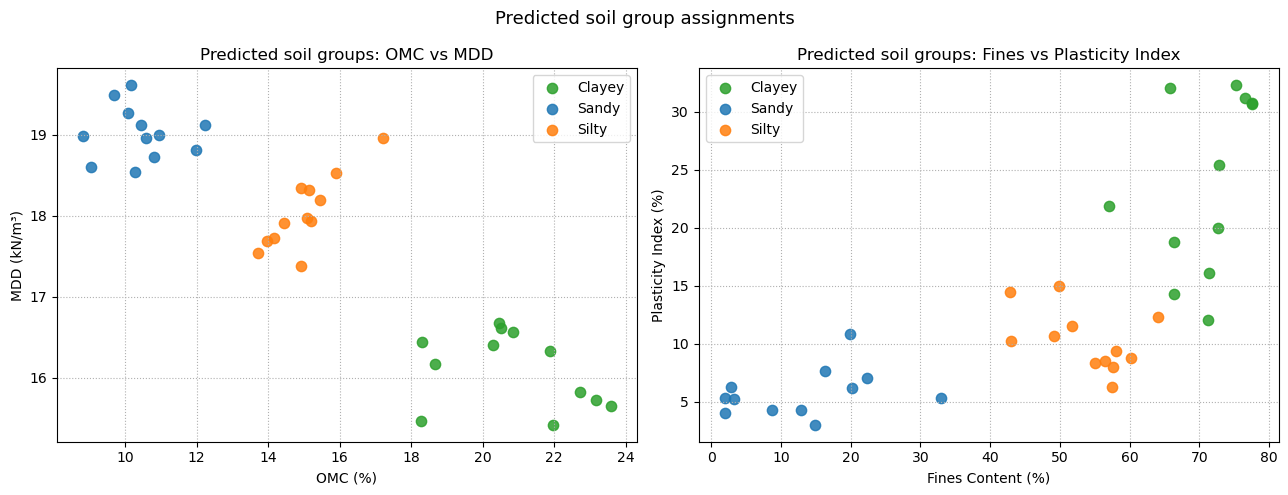


=== Tests per predicted soil group ===


soil_group
Sandy     12
Silty     12
Clayey    12
Name: n_tests, dtype: int64

In [40]:
# Helper: scatter plot labeled by your predicted soil group
df_labeled = df_clustered.copy()
df_labeled["soil_group"] = df_labeled["cluster"].map(q5)

group_colors = {"Sandy": "tab:blue", "Silty": "tab:orange", "Clayey": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for group, grp_df in df_labeled.groupby("soil_group"):
    axes[0].scatter(grp_df["omc_pct"], grp_df["mdd_kN_m3"],
                    color=group_colors[group], label=group, s=55, alpha=0.85)
axes[0].set_xlabel("OMC (%)")
axes[0].set_ylabel("MDD (kN/m³)")
axes[0].set_title("Predicted soil groups: OMC vs MDD")
axes[0].legend()
axes[0].grid(True, linestyle=":", linewidth=0.8)

for group, grp_df in df_labeled.groupby("soil_group"):
    axes[1].scatter(grp_df["fines_pct"], grp_df["plasticity_index_pct"],
                    color=group_colors[group], label=group, s=55, alpha=0.85)
axes[1].set_xlabel("Fines Content (%)")
axes[1].set_ylabel("Plasticity Index (%)")
axes[1].set_title("Predicted soil groups: Fines vs Plasticity Index")
axes[1].legend()
axes[1].grid(True, linestyle=":", linewidth=0.8)

plt.suptitle("Predicted soil group assignments", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Tests per predicted soil group ===")
display(df_labeled["soil_group"].value_counts().rename("n_tests"))

### Compare against the instructor answer key

The file `instructor_answer_key.csv` contains the true soil group for each test. Run the cell below to see how well your cluster-to-group mapping recovered the original labels.

In [41]:
# Helper: compare predictions to the answer key
answer_key = pd.read_csv("resources/instructor_answer_key.csv")

comparison = df_labeled[["test_id", "soil_group"]].merge(
    answer_key, on="test_id"
)

# Rename answer key column if needed
true_col = [c for c in answer_key.columns if c != "test_id"][0]
comparison = comparison.rename(columns={true_col: "true_group"})

comparison["correct"] = comparison["soil_group"] == comparison["true_group"]
accuracy = comparison["correct"].mean()

print(f"Accuracy: {accuracy:.1%}  ({comparison['correct'].sum()}/{len(comparison)} tests correct)")
display(comparison)

Accuracy: 100.0%  (36/36 tests correct)


,test_id,soil_group,true_group,correct
0,T01,Sandy,Sandy,True
1,T02,Sandy,Sandy,True
2,T03,Sandy,Sandy,True
3,T04,Sandy,Sandy,True
4,T05,Sandy,Sandy,True
5,T06,Sandy,Sandy,True
6,T07,Sandy,Sandy,True
7,T08,Sandy,Sandy,True
8,T09,Sandy,Sandy,True
9,T10,Sandy,Sandy,True


#### Testing Cell:

In [42]:
# Check that q5 is a valid mapping with the correct soil-group names


""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion clusterSoils is getting some calculations wrong!
success_message: Function passes all test cases :D
""" # END TEST CONFIG

_valid_groups = {"Sandy", "Silty", "Clayey"}

assert isinstance(q5, dict), "q5 should be a dictionary"
assert set(q5.keys()) == {0, 1, 2}, \
    f"q5 should have keys {{0, 1, 2}}, got {set(q5.keys())}"
assert set(q5.values()) == _valid_groups, \
    f"q5 values must be {_valid_groups}, got {set(q5.values())}. Check spelling."
print("q5 ✓  format and label checks passed")

q5 ✓  format and label checks passed


## Reflection

Answer the following questions in the markdown cells provided.

### Reflection 1

Re-run the clustering using different variables in feature_cols. Compare the resulting patterns that the algorithm picks up in the data depending on what features you select.

**How does changing the features to run on change the clusterings. Are there any new associations that you can see?**

**Your answer:**

*[double-click to edit]*

### Reflection 2

Re-run `clusterSoils` with `k = 2` and `k = 4`. Describe what you observe in the resulting scatter plots.

**What happens to the silty group when $k = 2$? Does increasing to $k = 4$ produce a geotechnically meaningful fourth group, or does it split an existing group arbitrarily?**

**Your answer:**

*[double-click to edit]*

In [ ]:
# Exploration cell: try k=2 and k=4
# Re-use buildFeatureMatrix and clusterSoils from above

for k_test in [2, 4]:
    c_w, lbs = clusterSoils(features_whitened, k=k_test, seed=0)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(attributes.dropna(subset=feature_cols)["omc_pct"],
               attributes.dropna(subset=feature_cols)["mdd_kN_m3"],
               c=lbs, cmap="tab10", s=55, alpha=0.85)
    ax.set_xlabel("OMC (%)")
    ax.set_ylabel("MDD (kN/m³)")
    ax.set_title(f"K-means with k = {k_test}")
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()

### Reflection 3

K-means assumes that clusters are roughly **spherical and equal in size** in the feature space, and it uses Euclidean distance as its similarity measure.

**Give a concrete geotechnical scenario where these assumptions might cause K-means to incorrectly group two tests that a geotechnical engineer would classify differently. Use specific feature values in your example.**

**Your answer:**

*[double-click to edit]*